In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Housing.csv")


In [3]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.isnull().sum()


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


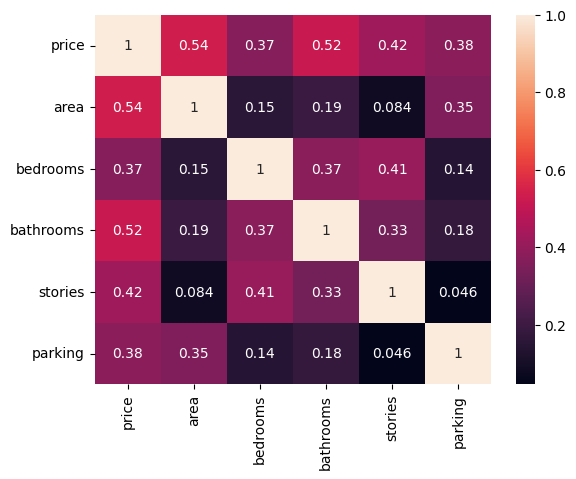

In [5]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


In [10]:
df.select_dtypes(include=["object"]).columns


Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [11]:
df.replace({'yes': 1, 'no': 0}, inplace=True)


/tmp/ipython-input-3867112939.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'yes': 1, 'no': 0}, inplace=True)


In [12]:
df = pd.get_dummies(df, drop_first=True)


In [14]:
X = df.drop("price", axis=1)
y = df["price"]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [22]:
model_features = X.columns


In [23]:
new_house_df = pd.DataFrame(
    data=np.zeros((1, len(model_features))),
    columns=model_features
)


# **Linear Regression**

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 1754318687330.6633
R2 Score: 0.6529242642153185


# **Real Time Prediction**

In [24]:
new_house_df['area'] = 1200
new_house_df['bedrooms'] = 3
new_house_df['bathrooms'] = 2
new_house_df['parking'] = 1
new_house_df['airconditioning'] = 1
new_house_df['basement'] = 0
new_house_df['guestroom'] = 0
new_house_df['mainroad'] = 1
new_house_df['prefarea'] = 0
new_house_df['stories'] = 2
new_house_df['hotwaterheating'] = 0
# Fully furnished → both 0
new_house_df['furnishingstatus_semi-furnished'] = 0
new_house_df['furnishingstatus_unfurnished'] = 0


In [25]:
predicted_price = model.predict(new_house_df)
print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")


Predicted House Price: ₹5,161,562.39


In [26]:
new_house_df['area'] = 1200
new_house_df['bedrooms'] = 3
new_house_df['bathrooms'] = 2
new_house_df['parking'] = 1
new_house_df['airconditioning'] = 1
new_house_df['basement'] = 0
new_house_df['guestroom'] = 0
new_house_df['mainroad'] = 1
new_house_df['prefarea'] = 0
new_house_df['stories'] = 2
new_house_df['hotwaterheating'] = 0
#Semi-furnished
new_house_df['furnishingstatus_semi-furnished'] = 1
new_house_df['furnishingstatus_unfurnished'] = 0


In [27]:
predicted_price = model.predict(new_house_df)
print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹5,034,680.57


In [28]:
new_house_df['area'] = 1200
new_house_df['bedrooms'] = 3
new_house_df['bathrooms'] = 2
new_house_df['parking'] = 1
new_house_df['airconditioning'] = 1
new_house_df['basement'] = 0
new_house_df['guestroom'] = 0
new_house_df['mainroad'] = 1
new_house_df['prefarea'] = 0
new_house_df['stories'] = 2
new_house_df['hotwaterheating'] = 0
#Unfurnished
new_house_df['furnishingstatus_semi-furnished'] = 0
new_house_df['furnishingstatus_unfurnished'] = 1


In [29]:
predicted_price = model.predict(new_house_df)
print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹4,747,917.32
